In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("data/Final Dataset - State of Data 2024 - Kaggle - df_survey_2024.csv")

In [4]:
df.shape

(5217, 403)

In [5]:
df.head()

,0.a_token,0.d_data/hora_envio,1.a_idade,1.a.1_faixa_idade,1.b_genero,1.c_cor/raca/etnia,1.d_pcd,1.e_experiencia_profissional_prejudicada,1.e.1_Não acredito que minha experiência profissional seja afetada,"1.e.2_Sim, devido a minha Cor/Raça/Etnia",...,"8.d.3_Entrando em contato com os times de negócio para definição do problema, identificar a solução e apresentação de resultados.",8.d.4_Desenvolvendo modelos de Machine Learning com o objetivo de colocar em produção em sistemas (produtos de dados).,"8.d.5_Colocando modelos em produção, criando os pipelines de dados, APIs de consumo e monitoramento.","8.d.6_Cuidando da manutenção de modelos de Machine Learning já em produção, atuando no monitoramento, ajustes e refatoração quando necessário.","8.d.7_Realizando construções de dashboards em ferramentas de BI como PowerBI, Tableau, Looker, Qlik, etc.","8.d.8_Utilizando ferramentas avançadas de estatística como SAS, SPSS, Stata etc, para realizar análises.","8.d.9_Criando e dando manutenção em ETLs, DAGs e automações de pipelines de dados.",8.d.10_Criando e gerenciando soluções de Feature Store e cultura de MLOps.,"8.d.11_Criando e mantendo a infra que meus modelos e soluções rodam (clusters, servidores, API, containers, etc.)",8.d.12_Treinando e aplicando LLM's para solucionar problemas de negócio.
0,reb94rv0msth7q4nreb94riaq80iz3yi,16/10/2024 11:19:17,18,17-21,Masculino,Branca,Não,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1zc66g69jjt49y32l1zc66g8wqj79m4e,16/10/2024 20:45:31,18,17-21,Masculino,Branca,Não,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,uu99wmam4n5kc2uu99wmydf0rk7l58f7,17/10/2024 18:10:59,18,17-21,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3ynsw7z0hl5hhpbfvaeqk73ynsw7z04l,22/10/2024 18:03:00,18,17-21,Masculino,Branca,Não,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,v6bji2ct5xckpl1uouv6bjiotkrf3b4f,23/10/2024 01:33:23,18,17-21,Masculino,Branca,Não,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5217 entries, 0 to 5216
Columns: 403 entries, 0.a_token to 8.d.12_Treinando e aplicando LLM's para solucionar problemas de negócio.
dtypes: bool(1), float64(323), int64(1), object(78)
memory usage: 16.0+ MB


In [7]:
df.columns.tolist()

['0.a_token',
 '0.d_data/hora_envio',
 '1.a_idade',
 '1.a.1_faixa_idade',
 '1.b_genero',
 '1.c_cor/raca/etnia',
 '1.d_pcd',
 '1.e_experiencia_profissional_prejudicada',
 '1.e.1_Não acredito que minha experiência profissional seja afetada',
 '1.e.2_Sim, devido a minha Cor/Raça/Etnia',
 '1.e.3_Sim, devido a minha identidade de gênero',
 '1.e.4_Sim, devido ao fato de ser PCD',
 '1.i.1_uf_onde_mora',
 '1.f.1_Quantidade de oportunidades de emprego/vagas recebidas',
 '1.f.2_Senioridade das vagas recebidas em relação à sua experiência',
 '1.f.3_Aprovação em processos seletivos/entrevistas',
 '1.f.4_Oportunidades de progressão de carreira',
 '1.f.5_Velocidade de progressão de carreira',
 '1.f.6_Nível de cobrança no trabalho/Stress no trabalho',
 '1.f.7_Atenção dada pelas pessoas diante das minhas opiniões e ideias',
 '1.f.8_Relação com outras pessoas da empresa, em momentos de trabalho',
 '1.f.9_Relação com outras pessoas da empresa, em momentos de integração e outros momentos fora do trabalho

In [8]:
df_filtrado = df[["1.a.1_faixa_idade", "1.b_genero", "1.c_cor/raca/etnia", "1.i.2_regiao_onde_mora", "1.l_nivel_de_ensino", "2.a_situação_de_trabalho", "2.f_cargo_atual", "2.g_nivel", "2.h_faixa_salarial", "2.i_tempo_de_experiencia_em_dados", "2.j_tempo_de_experiencia_em_ti", "2.k_satisfeito_atualmente"]]

In [9]:
df_filtrado.head()

,1.a.1_faixa_idade,1.b_genero,1.c_cor/raca/etnia,1.i.2_regiao_onde_mora,1.l_nivel_de_ensino,2.a_situação_de_trabalho,2.f_cargo_atual,2.g_nivel,2.h_faixa_salarial,2.i_tempo_de_experiencia_em_dados,2.j_tempo_de_experiencia_em_ti,2.k_satisfeito_atualmente
0,17-21,Masculino,Branca,Sul,Estudante de Graduação,Estagiário,Analista de Dados/Data Analyst,Júnior,de R$ 1.001/mês a R$ 2.000/mês,de 1 a 2 anos,de 1 a 2 anos,True
1,17-21,Masculino,Branca,Sul,Estudante de Graduação,Estagiário,Analista de BI/BI Analyst,Júnior,Menos de R$ 1.000/mês,Menos de 1 ano,Menos de 1 ano,True
2,17-21,Masculino,Parda,Sudeste,Estudante de Graduação,Empregado (CLT),Outra Opção,Júnior,de R$ 1.001/mês a R$ 2.000/mês,Não tenho experiência na área de dados,Não tive experiência na área de TI/Engenharia ...,False
3,17-21,Masculino,Branca,Sudeste,Estudante de Graduação,Estagiário,Analista de Dados/Data Analyst,Júnior,de R$ 1.001/mês a R$ 2.000/mês,Menos de 1 ano,Não tive experiência na área de TI/Engenharia ...,True
4,17-21,Masculino,Branca,Sudeste,Estudante de Graduação,Estagiário,Desenvolvedor/ Engenheiro de Software/ Analist...,Júnior,de R$ 1.001/mês a R$ 2.000/mês,Menos de 1 ano,Menos de 1 ano,True


In [10]:
df_filtrado = df_filtrado.rename(columns={
    "1.a.1_faixa_idade": "faixa_idade",
    "1.b_genero": "genero",
    "1.c_cor/raca/etnia": "raca",
    "1.i.2_regiao_onde_mora": "regiao",
    "1.l_nivel_de_ensino": "escolaridade",
    "2.a_situação_de_trabalho": "situacao_trabalho",
    "2.f_cargo_atual": "cargo",
    "2.g_nivel": "nivel",
    "2.h_faixa_salarial": "salario",
    "2.i_tempo_de_experiencia_em_dados": "tempo_experiencia_dados",
    "2.j_tempo_de_experiencia_em_ti": "tempo_experiencia_ti",
    "2.k_satisfeito_atualmente": "satisfacao"

    
})

In [11]:
df_filtrado.head()

,faixa_idade,genero,raca,regiao,escolaridade,situacao_trabalho,cargo,nivel,salario,tempo_experiencia_dados,tempo_experiencia_ti,satisfacao
0,17-21,Masculino,Branca,Sul,Estudante de Graduação,Estagiário,Analista de Dados/Data Analyst,Júnior,de R$ 1.001/mês a R$ 2.000/mês,de 1 a 2 anos,de 1 a 2 anos,True
1,17-21,Masculino,Branca,Sul,Estudante de Graduação,Estagiário,Analista de BI/BI Analyst,Júnior,Menos de R$ 1.000/mês,Menos de 1 ano,Menos de 1 ano,True
2,17-21,Masculino,Parda,Sudeste,Estudante de Graduação,Empregado (CLT),Outra Opção,Júnior,de R$ 1.001/mês a R$ 2.000/mês,Não tenho experiência na área de dados,Não tive experiência na área de TI/Engenharia ...,False
3,17-21,Masculino,Branca,Sudeste,Estudante de Graduação,Estagiário,Analista de Dados/Data Analyst,Júnior,de R$ 1.001/mês a R$ 2.000/mês,Menos de 1 ano,Não tive experiência na área de TI/Engenharia ...,True
4,17-21,Masculino,Branca,Sudeste,Estudante de Graduação,Estagiário,Desenvolvedor/ Engenheiro de Software/ Analist...,Júnior,de R$ 1.001/mês a R$ 2.000/mês,Menos de 1 ano,Menos de 1 ano,True


In [12]:
df_filtrado.isnull().sum()

faixa_idade                   0
genero                        0
raca                          0
regiao                      142
escolaridade                  0
situacao_trabalho             0
cargo                      1399
nivel                      1399
salario                     354
tempo_experiencia_dados     354
tempo_experiencia_ti        354
satisfacao                  354
dtype: int64

In [13]:
df_filtrado = df_filtrado.dropna(subset=["cargo"])

In [14]:
df_filtrado.shape

(3818, 12)

In [15]:
df_filtrado["salario"].unique()

array(['de R$ 1.001/mês a R$ 2.000/mês', 'Menos de R$ 1.000/mês',
       'de R$ 6.001/mês a R$ 8.000/mês', 'de R$ 3.001/mês a R$ 4.000/mês',
       'de R$ 2.001/mês a R$ 3.000/mês', 'de R$ 4.001/mês a R$ 6.000/mês',
       'de R$ 8.001/mês a R$ 12.000/mês',
       'de R$ 12.001/mês a R$ 16.000/mês',
       'de R$ 30.001/mês a R$ 40.000/mês',
       'de R$ 20.001/mês a R$ 25.000/mês',
       'de R$ 16.001/mês a R$ 20.000/mês',
       'de R$ 25.001/mês a R$ 30.000/mês', 'Acima de R$ 40.001/mês'],
      dtype=object)

In [16]:
mapa_salario = {
    'Menos de R$ 1.000/mês': 500,
    'de R$ 1.001/mês a R$ 2.000/mês': 1500,
    'de R$ 2.001/mês a R$ 3.000/mês': 2500,
    'de R$ 3.001/mês a R$ 4.000/mês': 3500,
    'de R$ 4.001/mês a R$ 6.000/mês': 5000,
    'de R$ 6.001/mês a R$ 8.000/mês': 7000,
    'de R$ 8.001/mês a R$ 12.000/mês': 10000,
    'de R$ 12.001/mês a R$ 16.000/mês': 14000,
    'de R$ 16.001/mês a R$ 20.000/mês': 18000,
    'de R$ 20.001/mês a R$ 25.000/mês': 22500,
    'de R$ 25.001/mês a R$ 30.000/mês': 27500,
    'de R$ 30.001/mês a R$ 40.000/mês': 35000,
    'Acima de R$ 40.001/mês': 45000
}

df_filtrado["salario_num"] = df_filtrado["salario"].map(mapa_salario)

In [17]:
df_filtrado["salario_num"].mean()

np.float64(9864.195914091148)

In [18]:
df_filtrado["nivel"].unique()

array(['Júnior', 'Pleno', 'Sênior'], dtype=object)

In [19]:
df_filtrado.groupby("nivel")["salario_num"].mean()

nivel
Júnior     4157.258065
Pleno      8047.204067
Sênior    14603.941513
Name: salario_num, dtype: float64

In [20]:
salario_por_nivel = df_filtrado.groupby("nivel")["salario_num"].mean().reset_index()

In [21]:
salario_por_nivel

,nivel,salario_num
0,Júnior,4157.258065
1,Pleno,8047.204067
2,Sênior,14603.941513


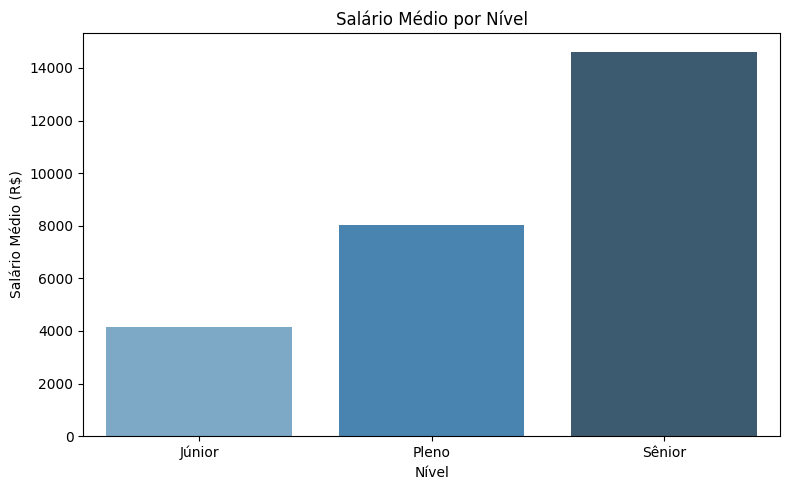

In [22]:
os.makedirs("imagens", exist_ok=True)
plt.figure(figsize=(8,5))
sns.barplot(data=salario_por_nivel, x="nivel", y="salario_num", hue="nivel", palette="Blues_d", legend=False)
plt.title("Salário Médio por Nível")
plt.xlabel("Nível")
plt.ylabel("Salário Médio (R$)")
plt.tight_layout()
plt.savefig("imagens/salario_por_nivel.png", dpi=150, bbox_inches="tight")
plt.show()

In [23]:
df_filtrado["cargo"].unique()

array(['Analista de Dados/Data Analyst', 'Analista de BI/BI Analyst',
       'Outra Opção',
       'Desenvolvedor/ Engenheiro de Software/ Analista de Sistemas',
       'Engenheiro de Dados/Data Engineer/Data Architect',
       'Analytics Engineer', 'Analista de Negócios/Business Analyst',
       'Analista de Suporte/Analista Técnico',
       'Cientista de Dados/Data Scientist', 'Professor/Pesquisador',
       'Engenheiro de Machine Learning/ML Engineer/AI Engineer',
       'Data Product Manager/ Product Manager (PM/APM/DPM/GPM/PO)',
       'Outras Engenharias (não inclui dev)',
       'Arquiteto de Dados/Data Architect', 'Estatístico'], dtype=object)

In [24]:
mapa_cargo = {
    'Analista de Dados/Data Analyst': 'Analista de Dados',
    'Analista de BI/BI Analyst': 'Analista de BI',
    'Engenheiro de Dados/Data Engineer/Data Architect': 'Engenheiro de Dados',
    'Cientista de Dados/Data Scientist': 'Cientista de Dados',
    'Engenheiro de Machine Learning/ML Engineer/AI Engineer': 'Eng. Machine Learning',
    'Analytics Engineer': 'Analytics Engineer',
    'Analista de Negócios/Business Analyst': 'Analista de Negócios',
    'Desenvolvedor/ Engenheiro de Software/ Analista de Sistemas': 'Desenvolvedor',
    'Data Product Manager/ Product Manager (PM/APM/DPM/GPM/PO)': 'Product Manager',
    'Arquiteto de Dados/Data Architect': 'Arquiteto de Dados',
    'Analista de Suporte/Analista Técnico': 'Analista de Suporte',
    'Professor/Pesquisador': 'Professor/Pesquisador',
    'Outras Engenharias (não inclui dev)': 'Outras Engenharias',
    'Estatístico': 'Estatístico',
    'Outra Opção': 'Outro'
}

df_filtrado["cargo"] = df_filtrado["cargo"].map(mapa_cargo)

In [25]:
df_filtrado.groupby("cargo")["salario_num"].mean()

cargo
Analista de BI            6511.363636
Analista de Dados         8007.314525
Analista de Negócios      8910.326087
Analista de Suporte       5398.734177
Analytics Engineer       10872.807018
Arquiteto de Dados       15875.000000
Cientista de Dados       11865.356623
Desenvolvedor             9274.590164
Eng. Machine Learning    15839.805825
Engenheiro de Dados      12876.019576
Estatístico               7647.058824
Outras Engenharias       10396.551724
Outro                     6921.259843
Product Manager          11931.250000
Professor/Pesquisador     7690.476190
Name: salario_num, dtype: float64

In [26]:
salario_por_cargo = df_filtrado.groupby("cargo")["salario_num"].mean().reset_index()

In [27]:
salario_por_cargo = salario_por_cargo.sort_values("salario_num", ascending=False)

In [28]:
salario_por_cargo

,cargo,salario_num
5,Arquiteto de Dados,15875.000000
8,Eng. Machine Learning,15839.805825
9,Engenheiro de Dados,12876.019576
13,Product Manager,11931.250000
6,Cientista de Dados,11865.356623
4,Analytics Engineer,10872.807018
11,Outras Engenharias,10396.551724
7,Desenvolvedor,9274.590164
2,Analista de Negócios,8910.326087
1,Analista de Dados,8007.314525


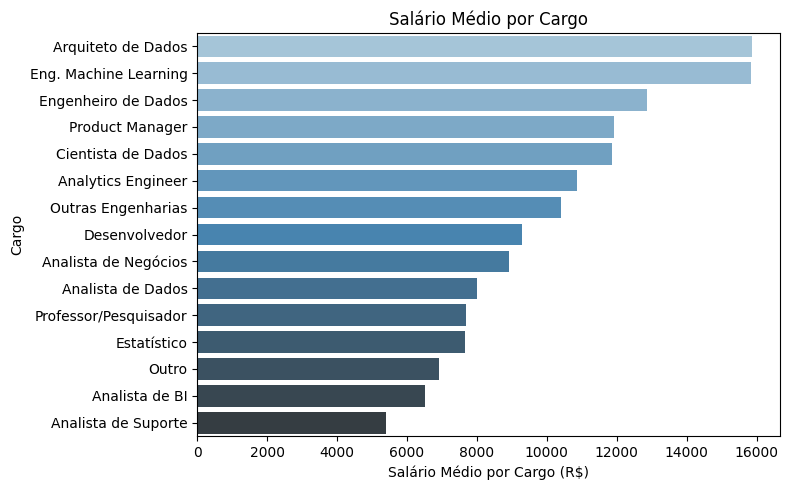

In [29]:
plt.figure(figsize=(8,5))
sns.barplot(data=salario_por_cargo, y="cargo", x="salario_num", hue="cargo", palette="Blues_d", legend=False)
plt.title("Salário Médio por Cargo")
plt.ylabel("Cargo")
plt.xlabel("Salário Médio por Cargo (R$)")
plt.tight_layout()
plt.savefig("imagens/salario_por_cargo.png", dpi=150, bbox_inches="tight")
plt.show()


In [30]:
df_filtrado["regiao"].unique()

array(['Sul', 'Sudeste', 'Nordeste', 'Centro-oeste', 'Norte', nan],
      dtype=object)

In [31]:
salario_por_regiao = df_filtrado.groupby("regiao")["salario_num"].mean().reset_index()

In [32]:
salario_por_regiao = salario_por_regiao.sort_values("salario_num", ascending=False)

In [33]:
salario_por_regiao

,regiao,salario_num
3,Sudeste,10069.512740
4,Sul,8993.309002
2,Norte,8900.000000
1,Nordeste,8798.128342
0,Centro-oeste,8695.833333


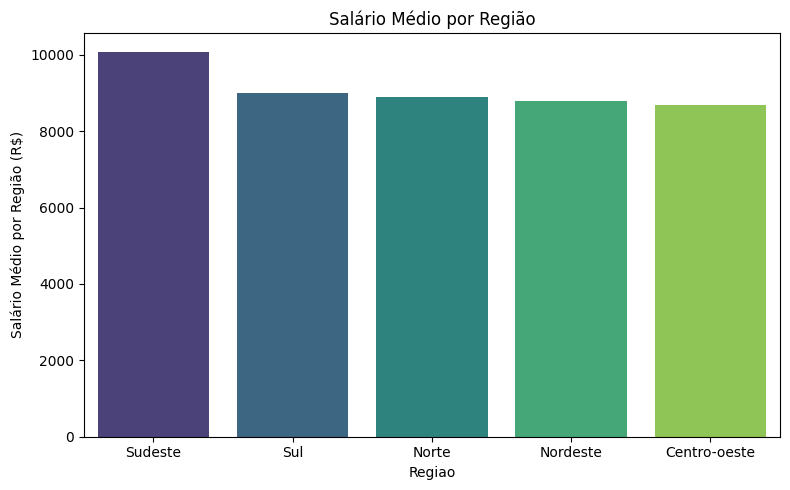

In [34]:
plt.figure(figsize=(8,5))
sns.barplot(data=salario_por_regiao, x="regiao", y="salario_num", hue="regiao", palette="viridis", legend=False)
plt.title("Salário Médio por Região")
plt.xlabel("Regiao")
plt.ylabel("Salário Médio por Região (R$)")
plt.tight_layout()
plt.savefig("imagens/salario_por_regiao.png", dpi=150, bbox_inches="tight")
plt.show()

In [35]:
df_filtrado["genero"].value_counts()

genero
Masculino               2858
Feminino                 943
Prefiro não informar      12
Outro                      5
Name: count, dtype: int64

In [36]:
contagem_genero

NameError: name 'contagem_genero' is not defined

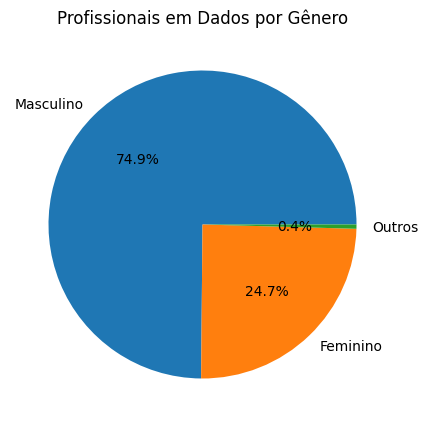

In [ ]:
contagem_genero = df_filtrado["genero"].value_counts()
contagem_genero = df_filtrado["genero"].value_counts()
contagem_genero["Outros"] = contagem_genero[["Prefiro não informar", "Outro"]].sum()
contagem_genero = contagem_genero.drop(["Prefiro não informar", "Outro"])

plt.figure(figsize=(8,5))
plt.pie(contagem_genero, labels=contagem_genero.index, autopct="%1.1f%%")
plt.title("Profissionais em Dados por Gênero")
plt.savefig("imagens/contagem_genero.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
df_filtrado["faixa_idade"].unique()

array(['17-21', '22-24', '25-29', '30-34', '35-39', '40-44', '45-49',
       '50-54', '55+'], dtype=object)

In [ ]:
df_filtrado["faixa_idade"].value_counts()

faixa_idade
25-29    1238
30-34    1095
35-39     535
22-24     374
40-44     254
17-21     134
45-49     109
50-54      54
55+        25
Name: count, dtype: int64

In [ ]:
ordem = ['17-21', '22-24', '25-29', '30-34', '35-39', '40-44', '45-49', '50-54', '55+']

contagem_idade = df_filtrado["faixa_idade"].value_counts().reindex(ordem)

In [ ]:
contagem_idade

faixa_idade
17-21     134
22-24     374
25-29    1238
30-34    1095
35-39     535
40-44     254
45-49     109
50-54      54
55+        25
Name: count, dtype: int64

In [ ]:
contagem_idade = contagem_idade.reset_index()
contagem_idade.columns = ["faixa_idade", "quantidade"]

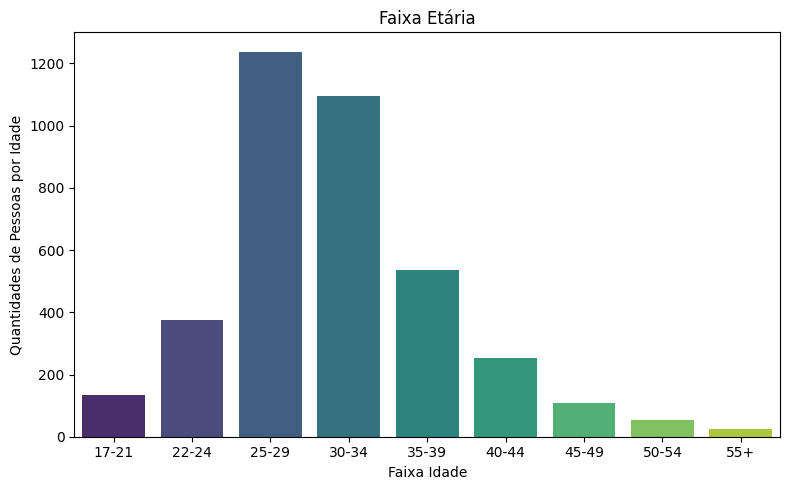

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(data=contagem_idade, x="faixa_idade", y="quantidade", hue="faixa_idade", palette="viridis", legend=False)
plt.title("Faixa Etária")
plt.xlabel("Faixa Idade")
plt.ylabel("Quantidades de Pessoas por Idade")
plt.tight_layout()
plt.savefig("imagens/qtd_faixa_idade.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
df_filtrado["nivel"].unique()

array(['Júnior', 'Pleno', 'Sênior'], dtype=object)

In [ ]:
df_filtrado["nivel"].value_counts()

nivel
Sênior    1573
Pleno     1377
Júnior     868
Name: count, dtype: int64

In [ ]:
ordem_nivel = ["Júnior", "Pleno", "Sênior"]
contagem_nivel = df_filtrado["nivel"].value_counts().reindex(ordem_nivel)

In [ ]:
contagem_nivel

nivel
Júnior     868
Pleno     1377
Sênior    1573
Name: count, dtype: int64

In [ ]:
contagem_nivel = contagem_nivel.reset_index()
contagem_nivel.columns = ["nivel", "quantidade"]

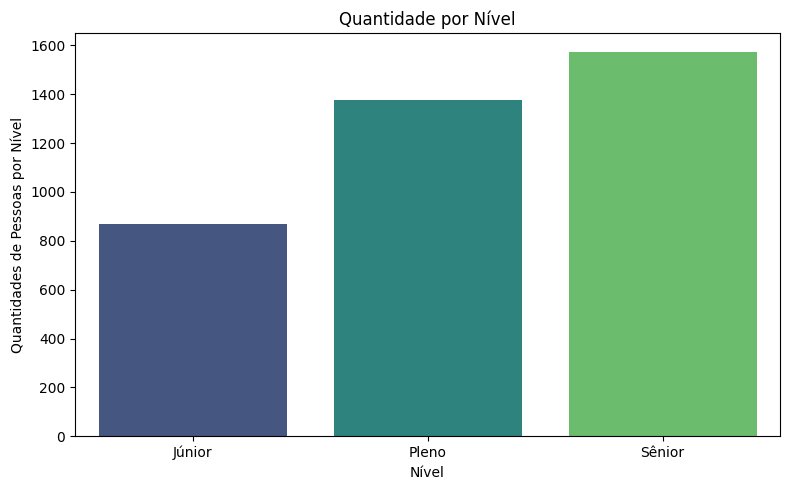

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(data=contagem_nivel, x="nivel", y="quantidade", hue="nivel", palette="viridis", legend=False)
plt.title("Quantidade por Nível")
plt.xlabel("Nível")
plt.ylabel("Quantidades de Pessoas por Nível")
plt.tight_layout()
plt.savefig("imagens/qtd_nivel.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
df_filtrado["escolaridade"].unique()

array(['Estudante de Graduação', 'Graduação/Bacharelado',
       'Não tenho graduação formal', 'Pós-graduação', 'Doutorado ou Phd',
       'Mestrado', 'Prefiro não informar'], dtype=object)

In [ ]:
mapa_escolaridade = {
'Estudante de Graduação' : 'Graduação (cursando)',
'Graduação/Bacharelado'      : 'Graduação',
'Pós-graduação'              : 'Pós-graduação',
'Mestrado'                   : 'Mestrado',
'Doutorado ou Phd'           : 'Doutorado',
'Não tenho graduação formal' : 'Sem graduação',
'Prefiro não informar'       : 'Sem graduação'
}

df_filtrado["escolaridade"] = df_filtrado["escolaridade"].map(mapa_escolaridade)

In [ ]:
df_filtrado["escolaridade"].value_counts()

escolaridade
Graduação               1374
Pós-graduação           1323
Graduação (cursando)     465
Mestrado                 438
Doutorado                150
Sem graduação             68
Name: count, dtype: int64

In [ ]:
contagem_escolaridade = df_filtrado["escolaridade"].value_counts().reset_index()
contagem_escolaridade.columns = ["escolaridade", "quantidade"]

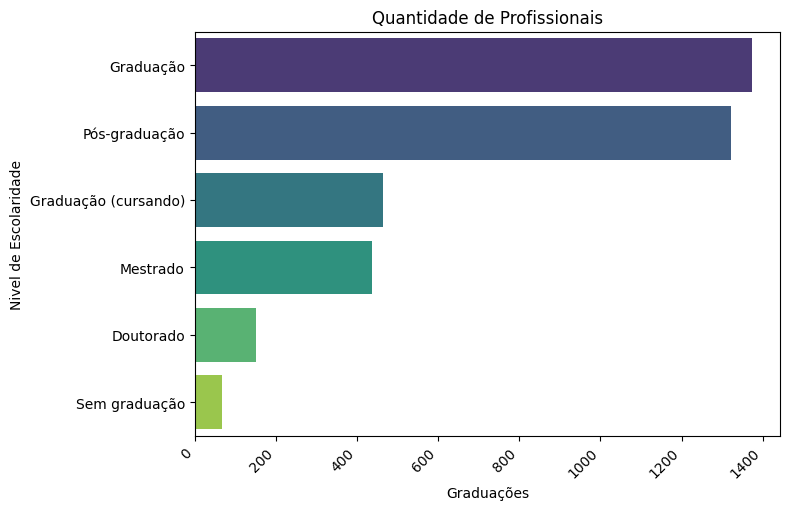

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(data=contagem_escolaridade, y="escolaridade", x="quantidade", hue="escolaridade", palette="viridis", legend=False)
plt.title("Quantidade de Profissionais")
plt.xlabel("Graduações")
plt.ylabel("Nivel de Escolaridade")
plt.tight_layout()
plt.savefig("imagens/qtd_nivel_escolaridade.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
df_filtrado["raca"].unique()

array(['Branca', 'Parda', 'Preta', 'Outra', 'Amarela',
       'Prefiro não informar', 'Indígena'], dtype=object)

In [ ]:
df_filtrado["raca"].value_counts()

raca
Branca                  2526
Parda                    884
Preta                    262
Amarela                  115
Prefiro não informar      20
Indígena                   7
Outra                      4
Name: count, dtype: int64

In [ ]:
contagem_raca = df_filtrado["raca"].value_counts().reset_index()
contagem_raca.columns = ["raca", "quantidade"]

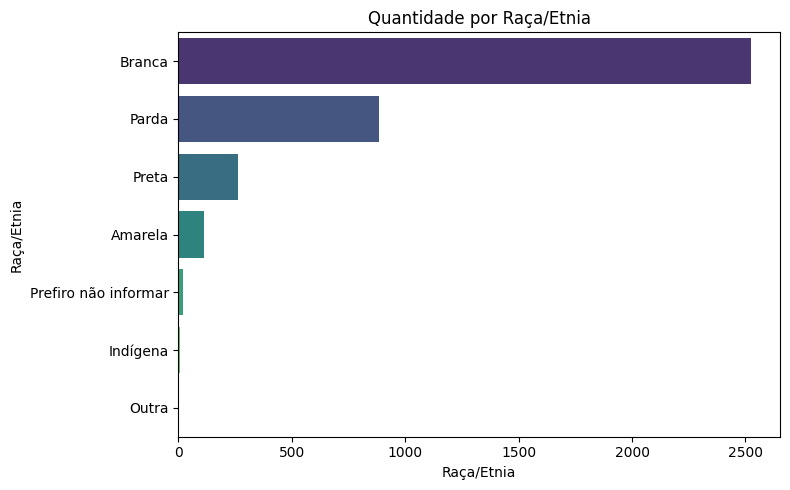

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(data=contagem_raca, y="raca", x="quantidade", hue="raca", palette="viridis", legend=False)
plt.title("Quantidade por Raça/Etnia")
plt.xlabel("Raça/Etnia")
plt.ylabel("Raça/Etnia")
plt.tight_layout()
plt.savefig("imagens/qtd_raca_etnia.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
df_filtrado["cargo"].unique()

array(['Analista de Dados', 'Analista de BI', 'Outro', 'Desenvolvedor',
       'Engenheiro de Dados', 'Analytics Engineer',
       'Analista de Negócios', 'Analista de Suporte',
       'Cientista de Dados', 'Professor/Pesquisador',
       'Eng. Machine Learning', 'Product Manager', 'Outras Engenharias',
       'Arquiteto de Dados', 'Estatístico'], dtype=object)

In [ ]:
df_filtrado["cargo"].value_counts()

cargo
Analista de Dados        957
Cientista de Dados       687
Engenheiro de Dados      613
Analista de BI           396
Outro                    254
Analytics Engineer       228
Analista de Negócios     184
Desenvolvedor            122
Eng. Machine Learning    103
Product Manager           80
Analista de Suporte       79
Arquiteto de Dados        48
Outras Engenharias        29
Professor/Pesquisador     21
Estatístico               17
Name: count, dtype: int64

In [ ]:
contagem_cargo = df_filtrado["cargo"].value_counts().reset_index()
contagem_cargo.columns = ["cargo", "quantidade"]
contagem_cargo = contagem_cargo.head(10)

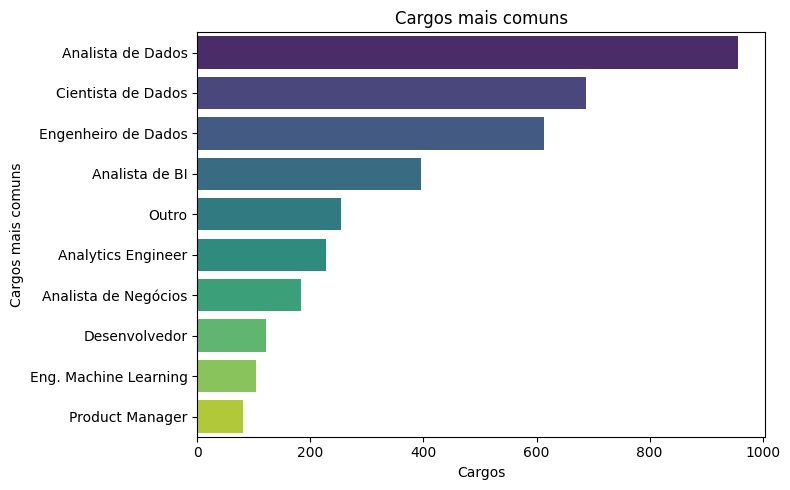

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(data=contagem_cargo, y="cargo", x="quantidade", hue="cargo", palette="viridis", legend=False)
plt.title("Cargos mais comuns")
plt.xlabel("Cargos")
plt.ylabel("Cargos mais comuns")
plt.tight_layout()
plt.savefig("imagens/cargos_comuns.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
df_filtrado["satisfacao"].unique()

array([True, False], dtype=object)

In [ ]:
satisfacao_geral = df_filtrado["satisfacao"].mean() * 100
print(f"{satisfacao_geral:.1f}% dos profissionais estão satisfeitos")

67.3% dos profissionais estão satisfeitos


In [ ]:
satisfacao_nivel = df_filtrado.groupby("nivel")["satisfacao"].mean().reset_index()
satisfacao_nivel.columns = ["nivel", "percentual_satisfeito"]
satisfacao_nivel["percentual_satisfeito"] = satisfacao_nivel["percentual_satisfeito"] * 100

In [ ]:
satisfacao_nivel

,nivel,percentual_satisfeito
0,Júnior,61.981567
1,Pleno,64.197531
2,Sênior,73.045137


In [ ]:
df_filtrado["regiao"].value_counts()

regiao
Sudeste         2237
Sul              822
Nordeste         374
Centro-oeste     240
Norte             50
Name: count, dtype: int64

In [ ]:
contagem_regiao = df_filtrado["regiao"].value_counts().reset_index()
contagem_regiao.columns = ["regiao", "quantidade"]

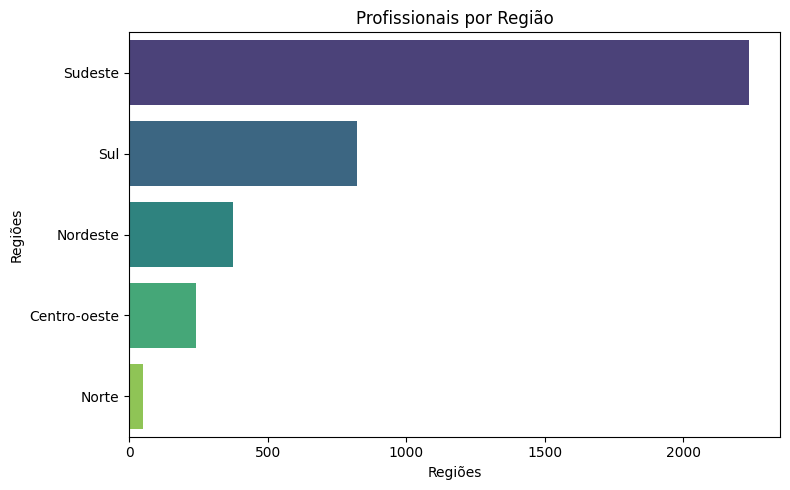

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(data=contagem_regiao, y="regiao", x="quantidade", hue="regiao", palette="viridis", legend=False)
plt.title("Profissionais por Região")
plt.xlabel("Regiões")
plt.ylabel("Regiões")
plt.tight_layout()
plt.savefig("imagens/qtd_regiao.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
df_filtrado["tempo_experiencia_dados"].value_counts()

tempo_experiencia_dados
de 3 a 4 anos                             1226
de 1 a 2 anos                              866
de 5 a 6 anos                              624
de 7 a 10 anos                             326
Menos de 1 ano                             318
Mais de 10 anos                            270
Não tenho experiência na área de dados     188
Name: count, dtype: int64

In [ ]:
mapa_exp = {
    'Não tenho experiência na área de dados': 0,
    'Menos de 1 ano': 0.5,
    'de 1 a 2 anos': 1.5,
    'de 3 a 4 anos': 3.5,
    'de 5 a 6 anos': 5.5,
    'de 7 a 10 anos': 8.5,
    'Mais de 10 anos': 12
}

df_filtrado["exp_dados_num"] = df_filtrado["tempo_experiencia_dados"].map(mapa_exp)

In [ ]:
exp_por_nivel = df_filtrado.groupby("nivel")["exp_dados_num"].mean().reset_index()
exp_por_nivel.columns = ["nivel", "media_exp"]

In [ ]:
exp_por_nivel

,nivel,media_exp
0,Júnior,1.404378
1,Pleno,3.227669
2,Sênior,6.057533


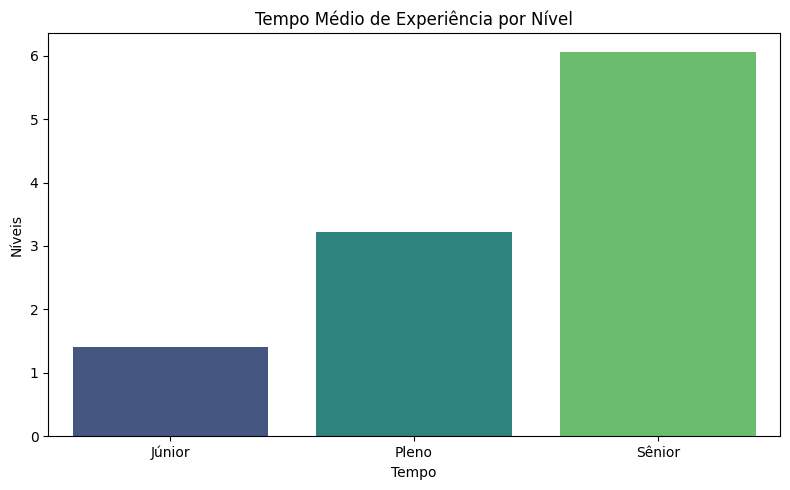

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(data=exp_por_nivel, x="nivel", y="media_exp", hue="nivel", palette="viridis", legend=False)
plt.title("Tempo Médio de Experiência por Nível")
plt.xlabel("Tempo")
plt.ylabel("Níveis")
plt.tight_layout()
plt.savefig("imagens/tempo_por_nivel_exp", dpi=150, bbox_inches="tight")
plt.show()

In [39]:
df_filtrado.to_csv("data/dados_tratados.csv", index=False)

In [ ]:
import sqlite3

conn = sqlite3.connect("data/mercado_dados.db")

df_filtrado.to_sql("profissionais", conn, if_exists="replace", index=False)

print("Banco criado com sucesso!")

Banco criado com sucesso!


In [ ]:
def query(sql):
    return pd.read_sql(sql, conn)

In [ ]:
query("""
SELECT nivel, ROUND(AVG(salario_num), 2) as salario_medio
FROM profissionais
GROUP BY nivel
ORDER BY salario_medio DESC
""")

,nivel,salario_medio
0,Sênior,14603.94
1,Pleno,8047.20
2,Júnior,4157.26


In [ ]:
query("""
SELECT cargo, ROUND(AVG(salario_num), 2) as salario_medio
FROM profissionais
GROUP BY cargo
ORDER BY salario_medio DESC 
LIMIT 5
""")

,cargo,salario_medio
0,Arquiteto de Dados,15875.00
1,Eng. Machine Learning,15839.81
2,Engenheiro de Dados,12876.02
3,Product Manager,11931.25
4,Cientista de Dados,11865.36


In [ ]:
query("""
SELECT regiao, ROUND(AVG(satisfacao) * 100, 2) as pct_satisfeito
FROM profissionais
GROUP BY regiao
ORDER BY pct_satisfeito DESC
LIMIT 5
""")

,regiao,pct_satisfeito
0,Sul,75.55
1,Sudeste,65.98
2,Nordeste,63.37
3,Centro-oeste,62.08
4,None,61.05


In [ ]:
query("""
SELECT regiao, ROUND(AVG(satisfacao) * 100, 2) as pct_satisfeito
FROM profissionais
WHERE regiao IS NOT NULL
GROUP BY regiao
ORDER BY pct_satisfeito DESC
""")

,regiao,pct_satisfeito
0,Sul,75.55
1,Sudeste,65.98
2,Nordeste,63.37
3,Centro-oeste,62.08
4,Norte,60.00


In [ ]:
query("""
SELECT cargo, nivel, COUNT(*) as total, ROUND(AVG(salario_num), 2) as salario_medio
FROM profissionais
WHERE cargo IS NOT NULL
GROUP BY cargo, nivel
ORDER BY salario_medio DESC
LIMIT 10
""")

,cargo,nivel,total,salario_medio
0,Eng. Machine Learning,Sênior,58,20362.07
1,Arquiteto de Dados,Sênior,37,17702.70
2,Engenheiro de Dados,Sênior,310,17548.39
3,Cientista de Dados,Sênior,339,15949.85
4,Outro,Sênior,60,14650.00
5,Analytics Engineer,Sênior,115,14260.87
6,Desenvolvedor,Sênior,44,13988.64
7,Outras Engenharias,Sênior,9,13277.78
8,Product Manager,Sênior,61,13163.93
9,Estatístico,Sênior,5,12500.00


In [37]:
df_filtrado["regiao"].value_counts()

regiao
Sudeste         2237
Sul              822
Nordeste         374
Centro-oeste     240
Norte             50
Name: count, dtype: int64